In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score
)
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from utils import custom_score, perform_random_search_cv, get_models, score_with_thresh, evaluate_holdout

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

SEED = 3105
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

# numbers of features to test
K_VALUES = [2, 3, 4, 5, 6, 7]
# number of random feature subsets
N_RANDOM = 3
# number of random hyperparameter configs per each model
N_ITER = 20
# fraction of a set we are allowed to contact
CONTACT_RATE = 0.2

## Prepare data

In [2]:
data_dir = Path("../../data")
X = pd.read_csv(data_dir / "x_train.txt", sep=" ")
y = pd.read_csv(data_dir / "y_train.txt", sep=" ").values.ravel()

with open("../feature_selection/selected_features.txt") as f:
    selected = [s.strip().strip("'").strip('"') for s in f.read().split(",")]

X = X[selected]
print(f"X: {X.shape}")

X: (5000, 30)


In [3]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=SEED
)

X_train.reset_index(drop=True, inplace=True)
X_val.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)

print(f"train: {X_train.shape}  val: {X_val.shape}  test: {X_test.shape}")

train: (3000, 30)  val: (1000, 30)  test: (1000, 30)


## Feature importance and subsets to test

In [4]:
rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
ranking = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(
    ascending=False
)
top15 = ranking.index[:15].tolist()


def random_subsets(k, n, excludes):
    seen = {frozenset(e) for e in excludes}
    subsets = []
    while len(subsets) < n:
        s = frozenset(rng.choice(top15, size=k, replace=False))
        if s not in seen:
            seen.add(s)
            subsets.append(sorted(s, key=top15.index))
    return subsets


subsets = {}
for k in K_VALUES:
    topk = ranking.index[:k].tolist()
    topk_1 = ranking.index[1 : k + 1].tolist()
    topk_2 = ranking.index[2 : k + 2].tolist()
    subsets[k] = (
        [("top", topk)]
        + [("top+1", topk_1)]
        + [("top+2", topk_2)]
        + [(f"rand_{i}", s) for i, s in enumerate(random_subsets(k, N_RANDOM, [topk, topk_1,topk_2]))]
    )
    print(f"k={k}: {len(subsets[k])} subsets")

k=2: 6 subsets
k=3: 6 subsets
k=4: 6 subsets
k=5: 6 subsets
k=6: 6 subsets
k=7: 6 subsets


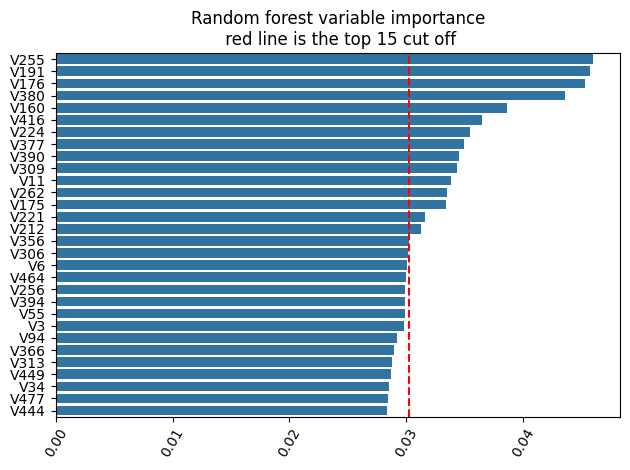

In [5]:
sns.barplot(ranking, orient='h')
plt.title("Random forest variable importance\n red line is the top 15 cut off")
plt.xticks(rotation=60, ha="center")
plt.axvline(x=ranking.iloc[15], color='red', linestyle='--')
plt.tight_layout()

## Random search CV

In [ ]:
results = perform_random_search_cv(X_train, y_train, seed=SEED, k_values=K_VALUES, n_iter=N_ITER, subsets=subsets)

In [6]:
results = pd.read_csv("cv_results_seed_3105.csv")
top = 20
k = 5
tmp = results[results["k"]==k].head(top)
tmp

,k,kind,model,cv_score,cv_score_std,features,best_params,accuracy,accuracy_std,balanced_accuracy,balanced_accuracy_std,precision,precision_std
99,5,top,GradientBoosting,305.0,37.416574,"['V255', 'V191', 'V176', 'V380', 'V160']",{'clf__learning_rate': np.float64(0.0771756727...,0.644000,0.005715,0.643848,0.005710,0.652088,0.004419
111,5,top,ExtraTrees,280.0,42.426407,"['V255', 'V191', 'V176', 'V380', 'V160']","{'clf__max_depth': 6, 'clf__min_samples_leaf':...",0.652000,0.012083,0.651556,0.012029,0.686284,0.016953
114,5,top,SVM_RBF,260.0,37.416574,"['V255', 'V191', 'V176', 'V380', 'V160']","{'clf__C': np.float64(0.1984825563044797), 'cl...",0.654000,0.004320,0.653822,0.004306,0.664269,0.003959
115,5,top,XGBoost,260.0,43.011626,"['V255', 'V191', 'V176', 'V380', 'V160']",{'clf__colsample_bytree': np.float64(0.7694648...,0.646667,0.008957,0.646478,0.008940,0.657410,0.008076
119,5,top+1,ExtraTrees,250.0,64.807407,"['V191', 'V176', 'V380', 'V160', 'V416']","{'clf__max_depth': 6, 'clf__min_samples_leaf':...",0.624667,0.006944,0.624142,0.006886,0.659023,0.009990
122,5,top+1,GradientBoosting,245.0,18.708287,"['V191', 'V176', 'V380', 'V160', 'V416']",{'clf__learning_rate': np.float64(0.0187075452...,0.621000,0.004546,0.620701,0.004482,0.636359,0.005842
124,5,top+1,XGBoost,235.0,42.426407,"['V191', 'V176', 'V380', 'V160', 'V416']",{'clf__colsample_bytree': np.float64(0.7694648...,0.622000,0.012329,0.621749,0.012275,0.634667,0.014811
125,5,top+1,RandomForest,235.0,53.385391,"['V191', 'V176', 'V380', 'V160', 'V416']","{'clf__max_depth': 10, 'clf__min_samples_leaf'...",0.625667,0.005735,0.625420,0.005735,0.638291,0.006967
126,5,top,RandomForest,235.0,12.247449,"['V255', 'V191', 'V176', 'V380', 'V160']","{'clf__max_depth': 10, 'clf__min_samples_leaf'...",0.648000,0.007789,0.647766,0.007712,0.661941,0.011171
127,5,top+1,SVM_RBF,230.0,77.781746,"['V191', 'V176', 'V380', 'V160', 'V416']","{'clf__C': np.float64(0.15166336526237675), 'c...",0.631000,0.004967,0.630634,0.004885,0.653224,0.009836


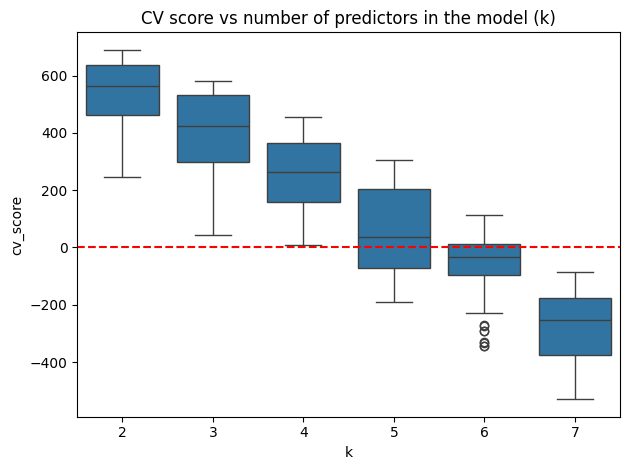

In [7]:
sns.boxplot(data=results, x="k", y="cv_score")
plt.title("CV score vs number of predictors in the model (k)")
plt.axhline(y=0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

## Evaluating top 20 models over 20 random seeds

In [ ]:
models = get_models()
for k in [2, 3, 4, 5, 6, 7]:
    summary_df = evaluate_holdout(k, results, X, y)
    print(f"{k} done")

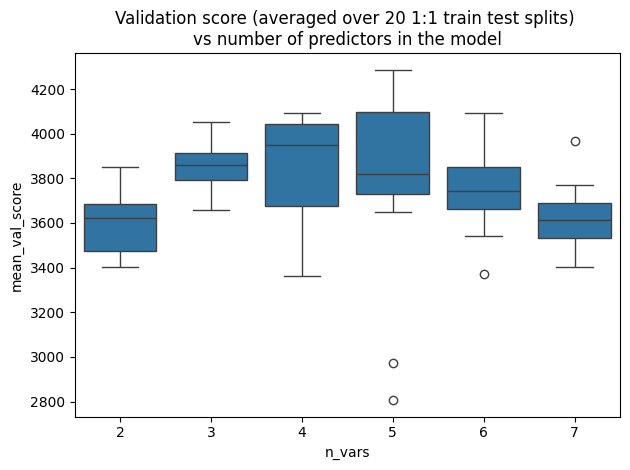

In [17]:
res = []
for k in [2, 3, 4, 5, 6, 7]:
    res.append(pd.read_csv(f"{k}_res.csv"))

res = pd.concat(res)
sns.boxplot(data=res, x="n_vars", y="mean_val_score")
plt.title("Validation score (averaged over 20 1:1 train test splits) \nvs number of predictors in the model")
plt.tight_layout()
plt.show()

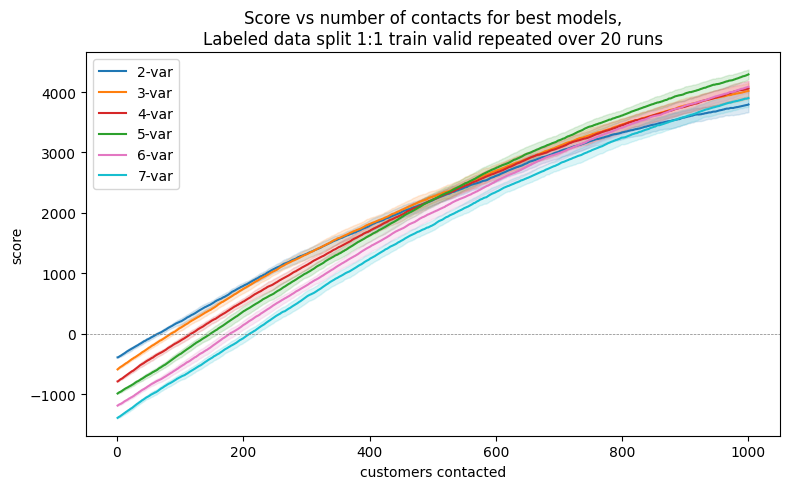

2 var: peak score 3794 EUR at 1000 contacts
3 var: peak score 4020 EUR at 1000 contacts
4 var: peak score 4060 EUR at 1000 contacts
5 var: peak score 4292 EUR at 1000 contacts
6 var: peak score 4086 EUR at 1000 contacts
7 var: peak score 3900 EUR at 1000 contacts


In [20]:
data_dir = Path("../../data")
X = pd.read_csv(data_dir / "x_train.txt", sep=" ")
y = pd.read_csv(data_dir / "y_train.txt", sep=" ").values.ravel()

feats_2var = [np.str_('V191'), np.str_('V416')]
feats_3var = ['V255', 'V191', 'V176']
feats_4var = ["V255", "V191", "V176", "V380"]
feats_5var = ["V255", "V191", "V176", "V380", "V160"]
feats_6var = ["V255", "V191", "V176", "V380", "V160", "V416"]
feats_7var = ["V255", "V191", "V176", "V380", "V160", "V416", "V224"]

params_2var = {"kernel": "rbf", "probability": True, 'C': np.float64(0.23522021535538676), 'gamma': np.float64(0.41659447770210534)}
params_3var = {"kernel": "rbf", "probability": True, 'C': np.float64(0.23522021535538676), 'gamma': np.float64(0.41659447770210534)}
params_4var = {"kernel": "rbf", "probability": True, "C": 0.41924993150460804, "gamma": 0.21971482785470117,}
params_5var = {"kernel": "rbf", "probability": True, "C": 0.1984825563044797, "gamma": 0.1314194139850142,}
params_6var = {"kernel": "rbf", "probability": True, "C": np.float64(6.393794237097354), "gamma": np.float64(0.016644299518966215),}
params_7var = {"kernel": "rbf", "probability": True, "C": np.float64(6.393794237097354), "gamma": np.float64(0.016644299518966215),}

max_contacts = 1000
n_splits = 20
seed = 0


def score_curve(feats, n_vars, clf_class, clf_params):
    grid = np.arange(1, max_contacts + 1)
    scores = np.zeros((n_splits, len(grid)))

    for s in range(n_splits):
        Xtr, Xva, ytr, yva = train_test_split(X[feats], y, test_size=0.5, stratify=y, random_state=seed + s)
        clf = clf_class(random_state=3105, **clf_params)
        clf.fit(Xtr, ytr)
        proba = clf.predict_proba(Xva)[:, 1]
        order = np.argsort(-proba)
        y_sorted = yva[order]
        cum_tp = np.cumsum(y_sorted == 1)
        cum_fp = np.cumsum(y_sorted == 0)
        n = min(max_contacts, len(y_sorted))
        score = cum_tp[:n] * 10 - cum_fp[:n] * 5 - n_vars * 200
        scores[s, :n] = score
        if n < len(grid):
            scores[s, n:] = score[-1]

    return grid, scores.mean(0), scores.std(0)


g, m2, s2 = score_curve(feats_2var, 2, SVC, params_2var)
g, m3, s3 = score_curve(feats_3var, 3, SVC, params_3var)
g, m4, s4 = score_curve(feats_4var, 4, SVC, params_4var)
g, m5, s5 = score_curve(feats_5var, 5, SVC, params_5var)
g, m6, s6 = score_curve(feats_6var, 6, SVC, params_6var)
g, m7, s7 = score_curve(feats_7var, 7, SVC, params_7var)


plt.figure(figsize=(8, 5))
for m, s, label, color in [
    (m2, s2, "2-var", "tab:blue"),
    (m3, s3, "3-var", "tab:orange"),
    (m4, s4, "4-var", "tab:red"),
    (m5, s5, "5-var", "tab:green"),
    (m6, s6, "6-var", "tab:pink"),
    (m7, s7, "7-var", "tab:cyan"),
]:
    plt.plot(g, m, label=label, color=color)
    plt.fill_between(g, m - s, m + s, alpha=0.15, color=color)

plt.axhline(0, color="gray", lw=0.5,linestyle='--')
plt.xlabel("customers contacted")
plt.ylabel("score")
plt.title("Score vs number of contacts for best models,\nLabeled data split 1:1 train valid repeated over 20 runs")
plt.legend()
plt.tight_layout()
plt.show()

for name, m in [
    ("2 var", m2),
    ("3 var", m3),
    ("4 var", m4),
    ("5 var", m5),
    ("6 var", m6),
    ("7 var", m7),
]:
    best_n = int(g[np.argmax(m)])
    print(f"{name}: peak score {m.max():.0f} EUR at {best_n} contacts")

## Final model and test prediction

In [2]:
data_dir = Path("../../data")
X_train = pd.read_csv(data_dir / "x_train.txt", sep=" ")
y_train = pd.read_csv(data_dir / "y_train.txt", sep=" ").values.ravel()
X_test = pd.read_csv(data_dir / "x_test.txt", sep=" ")

In [3]:
print(f"Final model: SVM")
features = ["V255", "V191", "V176", "V380", "V160"]
print(f"Chosen features: {features}")
params = {
    "kernel": "rbf",
    "probability": True,
    "C": 0.1984825563044797,
    "gamma": 0.1314194139850142,
    "random_state": 3105
}
print(f"Parameters: {params}")

svm = SVC(**params)
pipeline = Pipeline([("scaler", StandardScaler()), ("clf", svm)])
pipeline.fit(X_train[features], y_train)

Final model: SVM
Chosen features: ['V255', 'V191', 'V176', 'V380', 'V160']
Parameters: {'kernel': 'rbf', 'probability': True, 'C': 0.1984825563044797, 'gamma': 0.1314194139850142, 'random_state': 3105}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1984825563044797
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1314194139850142


In [4]:
print("Measures for train set")
top = 1000
pred_train = pipeline.predict_proba(X_train[features])[:, 1]
order = np.argsort(-pred_train)
p_sorted = pred_train[order]
print("probability at rank 1000:", round(p_sorted[999], 4))
top_indices = np.argsort(pred_train)[-top:]
pred_train = np.zeros(len(y_train))
pred_train[top_indices] = 1

print(f"score: {custom_score(y_train, pred_train, len(features))}")
print(f"accuracy: {accuracy_score(y_train, pred_train)}")
print(f"bal acc: {balanced_accuracy_score(y_train, pred_train)}")
print(f"precision: {precision_score(y_train, pred_train)}")
print(f"recall: {recall_score(y_train, pred_train)}")

Measures for train set
probability at rank 1000: 0.6738
score: 5775
accuracy: 0.6164
bal acc: 0.614962648739427
precision: 0.785
recall: 0.3155144694533762


### Prediction

In [5]:
pred = pipeline.predict_proba(X_test[features])[:,1]
order = np.argsort(-pred)
p_sorted = pred[order]
print("probability at rank 1000:", round(p_sorted[999], 4))
top = 1000
# indices of top 1000 probabilities
top_indices = np.argsort(pred)[-top:] + 1

probability at rank 1000: 0.6742


In [6]:
top_indices

array([1233, 1240,  456, 3990, 2972, 1052, 4337, 1503, 4900, 3203, 3308,
        820, 1643,  115, 1911, 3247,  266,  391,  382, 2649, 3158,  459,
       3953, 2307, 4113, 3184, 1885, 2255, 3889, 1364,  926, 1182, 3093,
       3738, 3468,  511, 2988, 3237, 4600, 3705,  333, 4504, 1178, 4146,
       1053, 1523, 3174, 1525, 4836, 1944, 2621, 2750, 1131, 4856, 4929,
       4559, 3083, 3511, 3707, 3186, 3394, 4986, 4957, 1997, 1079, 4655,
       4692, 1020, 2766, 2044, 2968,  350, 4527, 1937, 3558, 1009, 3161,
       1469, 2600, 2119,  584, 1144, 3292, 2313, 2665, 3504, 2054, 3854,
       1340, 3413, 2904, 4395, 4681, 1013, 4731, 2073, 4396, 4428, 1095,
       4256,  779, 1609, 4188, 2746, 4391,  556, 3016,  234, 4829, 1161,
        162, 4742, 3960, 3379, 4039, 2188, 1251, 4134, 4350, 3290, 4000,
       2368, 3026,  707, 2300, 4404, 2878, 3416, 2699,  861, 2251, 4522,
       4228, 1104, 3053, 2880, 1224, 3421, 1313, 1824, 2345, 2931, 2852,
       1232,  529, 4548, 3714, 2508,  291, 2899, 29

In [7]:
np.savetxt(fname="327185_327196_320585_obs.txt", X=top_indices, fmt='%d')

In [ ]:
# ["V255", "V191", "V176", "V380", "V160"]
# indexed from 1
var_ids = [255, 191, 176, 380, 160]
np.savetxt(fname="327185_327196_320585_vars.txt", X=var_ids, fmt='%d')

### Sanity check, that the distibutions of selected features match on train and test

  feature  ks_stat   p_value
0    V255   0.0170  0.465358
1    V191   0.0114  0.901389
2    V176   0.0212  0.211152
3    V380   0.0120  0.864333
4    V160   0.0210  0.220219


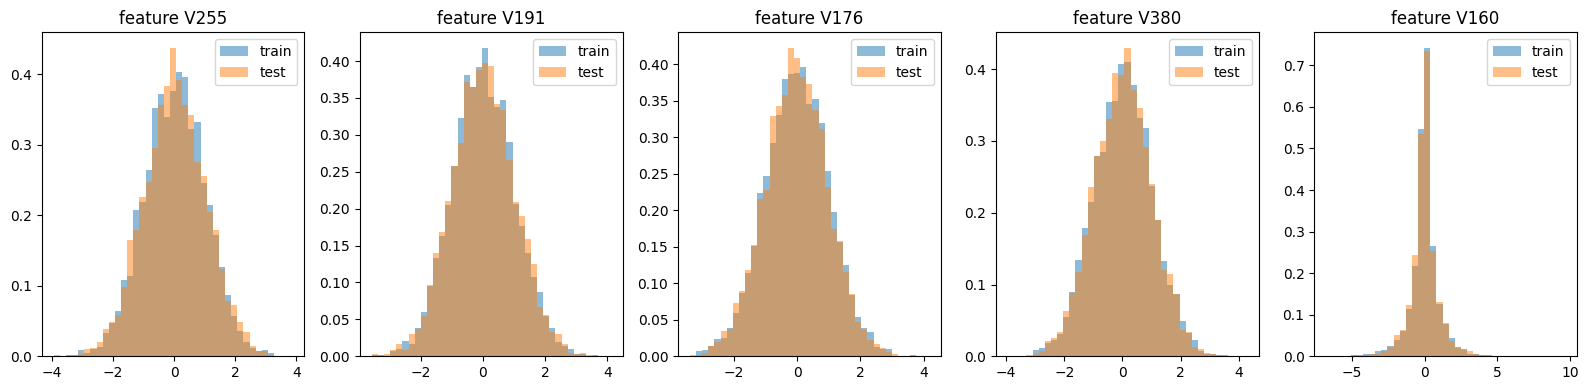

In [182]:
from scipy.stats import ks_2samp
data_dir = Path("../../data")
x_train = pd.read_csv(data_dir / "x_train.txt", sep=" ")
y_train = pd.read_csv(data_dir / "y_train.txt", sep=" ").values.ravel()
x_test = pd.read_csv(data_dir / "x_test.txt", sep=" ")
features = ["V255", "V191", "V176", "V380", "V160"]
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
ks_results = []
for i, f in enumerate(features):
    tr = x_train[f]
    te = x_test[f]
    lo = min(tr.min(), te.min())
    hi = max(tr.max(), te.max())
    bins = np.linspace(lo, hi, 40)
    axes[i].hist(tr, bins=bins, density=True, alpha=0.5, label="train")
    axes[i].hist(te, bins=bins, density=True, alpha=0.5, label="test")
    axes[i].set_title(f"feature {f}")
    axes[i].legend()

    stat, p = ks_2samp(tr, te)
    ks_results.append({
        "feature": f,
        "ks_stat": stat,
        "p_value": p
    })
ks_df = pd.DataFrame(ks_results)
print(ks_df)
plt.tight_layout()
plt.show()